In [16]:
from moscot.problems.time import TemporalProblem
import cellrank as cr
import scanpy as sc
from cellrank.kernels import RealTimeKernel
import scvelo as scv

import numpy as np
import re
import scipy
import json
from datetime import datetime

In [12]:
!pip install typeguard==4.0.1

  Using cached typeguard-4.0.1-py3-none-any.whl.metadata (3.7 kB)
Using cached typeguard-4.0.1-py3-none-any.whl (33 kB)
  Attempting uninstall: typeguard
    Found existing installation: typeguard 2.13.3
    Uninstalling typeguard-2.13.3:
      Successfully uninstalled typeguard-2.13.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffrax 0.6.2 requires typeguard==2.13.3, but you have typeguard 4.0.1 which is incompatible.


In [14]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [15]:
adata = sc.read_h5ad('/Users/annamaguza/Desktop/data/gut_data/gut_hs_fetal_epithelial_scVI_AM_06032025_145649_raw.h5ad')

## Create velocity kernel

In [18]:
scv.pp.filter_and_normalize(
    adata, min_shared_counts=20, n_top_genes=2000, subset_highly_variable=False
)

Filtered out 28191 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.


/Users/annamaguza/Library/Application Support/hatch/env/virtual/single-cell-project/0fJ3OPid/single_cell_project/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.


In [19]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30, random_state=0)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


computing moments based on connectivities
    finished (0:01:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


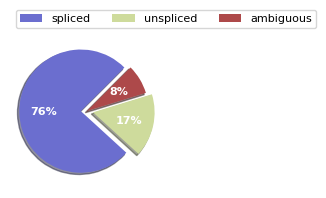

In [22]:
scv.pl.proportions(adata)

In [23]:
adata

AnnData object with n_obs × n_vars = 71712 × 15513
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [25]:
scv.tl.recover_dynamics(adata, n_jobs=8)

recovering dynamics (using 8/8 cores)
or disable the progress bar using `show_progress_bar=False`.


python(67952) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67953) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67954) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67955) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67956) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67957) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67958) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67959) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67960) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(67961) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


    finished (0:37:13) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [26]:
scv.tl.velocity(adata, mode="dynamical")

computing velocities
    finished (0:01:28) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [27]:
velo_kernel = cr.kernels.VelocityKernel(adata)

In [29]:
velo_kernel.compute_transition_matrix()

python(68367) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 71712/71712 [00:17<00:00, 4043.58cell/s]
python(68368) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 71712/71712 [00:16<00:00, 4407.86cell/s]


VelocityKernel[n=71712, model='deterministic', similarity='correlation', softmax_scale=2.501]

## Create the experimental time kernel

In [30]:
def extract_age(age_string):
    match = re.search(r'(\d+\.?\d*)', str(age_string))
    if match:
        return float(match.group(1))
    else:
        return np.nan

In [31]:
adata.obs['age_numeric'] = adata.obs['full_age'].apply(extract_age)

In [32]:
adata.obs["age_numeric"] = adata.obs["age_numeric"].astype(float)

In [33]:
adata.obs['cell_states'] = adata.obs['cell_states'].astype('str') + '_' + adata.obs['leiden_cluster'].astype('str')
adata.obs['cell_states'] = adata.obs['cell_states'].str.replace(r'_nan', '', regex=True)
adata.obs['cell_states'] = adata.obs['cell_states'].astype('category')

In [36]:
tp = TemporalProblem(adata)

In [37]:
tp = tp.prepare(time_key="age_numeric")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`       

In [38]:
tp = tp.solve(epsilon=1e-3, tau_a=0.95, scale_cost="mean")

INFO     Solving `19` problems                                                                                     
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1910, 3236)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(179, 6159)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(6082, 2191)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(2860, 11863)].                                 
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1835, 1402)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(11863, 1030)].                                 
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(4914, 1910)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(765,

In [39]:
tmk = RealTimeKernel.from_moscot(tp)

In [42]:
tmk.compute_transition_matrix(self_transitions="all", conn_weight=0.2, threshold="auto")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 59338.63time pair/s]


python(68443) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


RealTimeKernel[n=71712, threshold='auto', self_transitions='all']

## Combine kernels

In [43]:
combined_kernel = 0.7 * velo_kernel + 0.3 * tmk

In [44]:
estimator = cr.estimators.GPCCA(combined_kernel)

In [45]:
estimator.compute_schur(n_components=20)
estimator.compute_macrostates(n_states=9) 

: 

: 

: 